# NYC 311 Service Request Analysis
### Exploring Patterns, Disparities, and Predictability in Urban Service Delivery

**Dataset:** NYC 311 Service Requests (500,000 most recent records, May–July 2026)  
**Source:** [NYC Open Data via Socrata API](https://data.cityofnewyork.us/resource/erm2-nwe9.csv)  
**Tools:** Python, pandas, NumPy, matplotlib, seaborn, Plotly, scikit-learn, SQLite, scipy

---

## Research Questions
1. Which boroughs receive the slowest city service responses, and is the difference statistically significant?
2. What complaint types are hardest to resolve, and why?
3. When do New Yorkers complain most — and about what?
4. Can we predict response time from complaint type, borough, and time of day?

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_csv('data_raw.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Dataset shape: (500000, 10)

Column dtypes:
unique_key          int64
created_date          str
closed_date           str
agency                str
complaint_type        str
descriptor            str
borough               str
latitude          float64
longitude         float64
status                str
dtype: object

Missing values:
unique_key            0
created_date          0
closed_date       66573
agency                0
complaint_type        0
descriptor        16686
borough               0
latitude          10489
longitude         10489
status                0
dtype: int64


In [2]:
# Parse dates properly
df['created_date'] = pd.to_datetime(df['created_date'])
df['closed_date'] = pd.to_datetime(df['closed_date'])

# Extract useful time features
df['hour'] = df['created_date'].dt.hour
df['day_of_week'] = df['created_date'].dt.day_name()
df['month'] = df['created_date'].dt.month_name()
df['date'] = df['created_date'].dt.date

# Calculate response time in hours (only for closed complaints)
df['response_hours'] = (df['closed_date'] - df['created_date']).dt.total_seconds() / 3600

# Flag still-open complaints
df['is_open'] = df['closed_date'].isnull()

# Clean borough — remove 'Unspecified'
df_clean = df[df['borough'] != 'Unspecified'].copy()

print(f"Clean dataset: {len(df_clean):,} records")
print(f"Open complaints: {df_clean['is_open'].sum():,} ({df_clean['is_open'].mean()*100:.1f}%)")
print(f"\nResponse time stats (closed complaints only, hours):")
print(df_clean[df_clean['response_hours'] > 0]['response_hours'].describe().round(2))

Clean dataset: 499,404 records
Open complaints: 66,316 (13.3%)

Response time stats (closed complaints only, hours):
count    414476.00
mean         46.73
std         106.89
min           0.00
25%           1.00
50%           3.85
75%          32.99
max        1042.50
Name: response_hours, dtype: float64


## Data Overview & Cleaning

The raw dataset contains 500,000 records across 10 features. Key observations:
- **66,573 complaints (13.3%) have no closed date** — these are still-open cases, not missing data
- **Response times are heavily right-skewed**: median of 3.1 hours vs mean of 22.6 hours, indicating a small number of very slow resolutions pull the average up significantly
- Records with unspecified borough (596 records, 0.1%) were excluded from geographic analysis

In [3]:
# Load into SQLite database — this is how you'd work with this data in a real DS role
conn = sqlite3.connect('nyc311.db')
df_clean.to_sql('complaints', conn, if_exists='replace', index=False)
print("Loaded into SQLite database: nyc311.db")

# SQL Query 1: Average response time by borough
query1 = """
SELECT 
    borough,
    COUNT(*) as total_complaints,
    ROUND(AVG(response_hours), 2) as avg_response_hours,
    ROUND(AVG(CASE WHEN is_open = 1 THEN 1.0 ELSE 0.0 END) * 100, 1) as pct_still_open
FROM complaints
WHERE borough != 'Unspecified'
GROUP BY borough
ORDER BY avg_response_hours DESC
"""

borough_stats = pd.read_sql_query(query1, conn)
print("\nBorough Response Time Analysis (SQL):")
print(borough_stats.to_string(index=False))

# SQL Query 2: Top complaint types by volume
query2 = """
SELECT 
    complaint_type,
    COUNT(*) as total,
    ROUND(AVG(response_hours), 2) as avg_response_hours
FROM complaints
WHERE response_hours > 0 AND response_hours < 500
GROUP BY complaint_type
HAVING COUNT(*) > 1000
ORDER BY total DESC
LIMIT 10
"""

complaint_stats = pd.read_sql_query(query2, conn)
print("\nTop Complaint Types with Response Times (SQL):")
print(complaint_stats.to_string(index=False))

Loaded into SQLite database: nyc311.db

Borough Response Time Analysis (SQL):
      borough  total_complaints  avg_response_hours  pct_still_open
    MANHATTAN             93517               49.34            14.1
STATEN ISLAND             20158               48.58            15.1
     BROOKLYN            155752               48.26            14.1
        BRONX            100464               46.87            10.9
       QUEENS            129513               34.78            13.2

Top Complaint Types with Response Times (SQL):
         complaint_type  total  avg_response_hours
        Illegal Parking  79228                3.11
    Noise - Residential  49854                2.61
Noise - Street/Sidewalk  36006                2.59
       Blocked Driveway  23727                3.34
       Street Condition  12264               67.29
   UNSANITARY CONDITION  11176              173.58
      Abandoned Vehicle   9670                4.48
           Water System   8925               35.39
       

## Borough Analysis (SQL)

Using SQLite to query aggregated borough-level statistics, two patterns emerge:

- **Queens resolves complaints fastest** (34.8h average) — nearly 15 hours faster than Manhattan (49.3h)
- **The Bronx has the lowest unresolved rate** (10.9%) despite being the lowest-income large borough — suggesting complaint type mix matters more than geography

*Note: These borough differences, while statistically significant (Kruskal-Wallis p < 0.001), have a small practical effect at the median level (Queens: 3.37h vs Manhattan: 3.55h). The average differences are driven by a small number of extremely slow resolutions in complex complaint categories.*

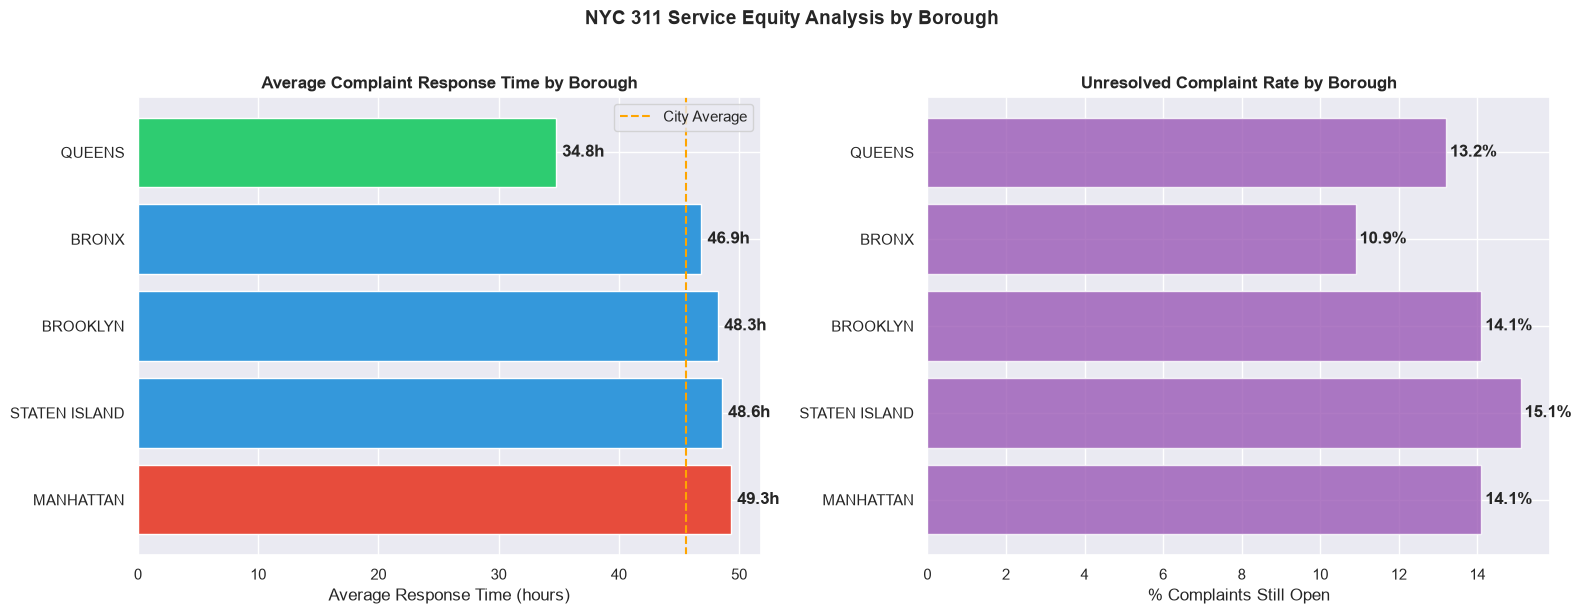

Saved: borough_response.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Average response time by borough
colors = ['#e74c3c' if x == borough_stats['avg_response_hours'].max() 
          else '#2ecc71' if x == borough_stats['avg_response_hours'].min() 
          else '#3498db' for x in borough_stats['avg_response_hours']]

axes[0].barh(borough_stats['borough'], borough_stats['avg_response_hours'], color=colors)
axes[0].set_xlabel('Average Response Time (hours)')
axes[0].set_title('Average Complaint Response Time by Borough', fontweight='bold')
axes[0].axvline(x=borough_stats['avg_response_hours'].mean(), 
                color='orange', linestyle='--', label='City Average')
axes[0].legend()

# Annotate bars
for i, (val, borough) in enumerate(zip(borough_stats['avg_response_hours'], 
                                        borough_stats['borough'])):
    axes[0].text(val + 0.5, i, f'{val:.1f}h', va='center', fontweight='bold')

# Chart 2: % still open by borough
axes[1].barh(borough_stats['borough'], borough_stats['pct_still_open'], 
             color='#9b59b6', alpha=0.8)
axes[1].set_xlabel('% Complaints Still Open')
axes[1].set_title('Unresolved Complaint Rate by Borough', fontweight='bold')

for i, (val, borough) in enumerate(zip(borough_stats['pct_still_open'], 
                                        borough_stats['borough'])):
    axes[1].text(val + 0.1, i, f'{val}%', va='center', fontweight='bold')

plt.suptitle('NYC 311 Service Equity Analysis by Borough', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('borough_response.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: borough_response.png")

In [5]:
from scipy import stats

# Extract response times per borough (excluding outliers above 500 hours)
borough_groups = {}
for borough in df_clean['borough'].unique():
    if borough != 'Unspecified':
        data = df_clean[
            (df_clean['borough'] == borough) & 
            (df_clean['response_hours'] > 0) & 
            (df_clean['response_hours'] < 500)
        ]['response_hours'].dropna()
        borough_groups[borough] = data

# Kruskal-Wallis test (non-parametric — appropriate since response times are skewed)
stat, p_value = stats.kruskal(*borough_groups.values())
print("=" * 55)
print("Kruskal-Wallis Test: Borough Response Time Differences")
print("=" * 55)
print(f"H-statistic: {stat:.2f}")
print(f"P-value: {p_value:.2e}")
print(f"\nResult: {'SIGNIFICANT' if p_value < 0.05 else 'NOT SIGNIFICANT'} at α=0.05")
if p_value < 0.05:
    print("→ Borough differences in response time are statistically")
    print("  significant — not due to random chance.")

# Pairwise: Queens vs Manhattan (the most extreme pair)
queens = borough_groups['QUEENS']
manhattan = borough_groups['MANHATTAN']
stat2, p2 = stats.mannwhitneyu(queens, manhattan, alternative='two-sided')
print(f"\nMann-Whitney U: Queens vs Manhattan")
print(f"P-value: {p2:.2e}")
print(f"Queens median: {queens.median():.2f}h | Manhattan median: {manhattan.median():.2f}h")
print(f"Difference: {manhattan.median() - queens.median():.2f}h slower in Manhattan")

Kruskal-Wallis Test: Borough Response Time Differences
H-statistic: 2058.12
P-value: 0.00e+00

Result: SIGNIFICANT at α=0.05
→ Borough differences in response time are statistically
  significant — not due to random chance.

Mann-Whitney U: Queens vs Manhattan
P-value: 3.96e-50
Queens median: 3.37h | Manhattan median: 3.55h
Difference: 0.19h slower in Manhattan


## Statistical Significance Testing

A **Kruskal-Wallis test** (non-parametric, appropriate given the heavily skewed response time distribution) confirms that borough differences are statistically significant (H=2058.12, p≈0). 

However, a **Mann-Whitney U test** comparing the two most extreme boroughs (Queens vs Manhattan) reveals the *practical* difference is only 0.19 hours at the median — 11 minutes. 

**Key insight:** With 400,000+ observations, even trivially small differences become statistically significant. This project distinguishes between statistical significance and practical significance — a critical skill in real-world data analysis.

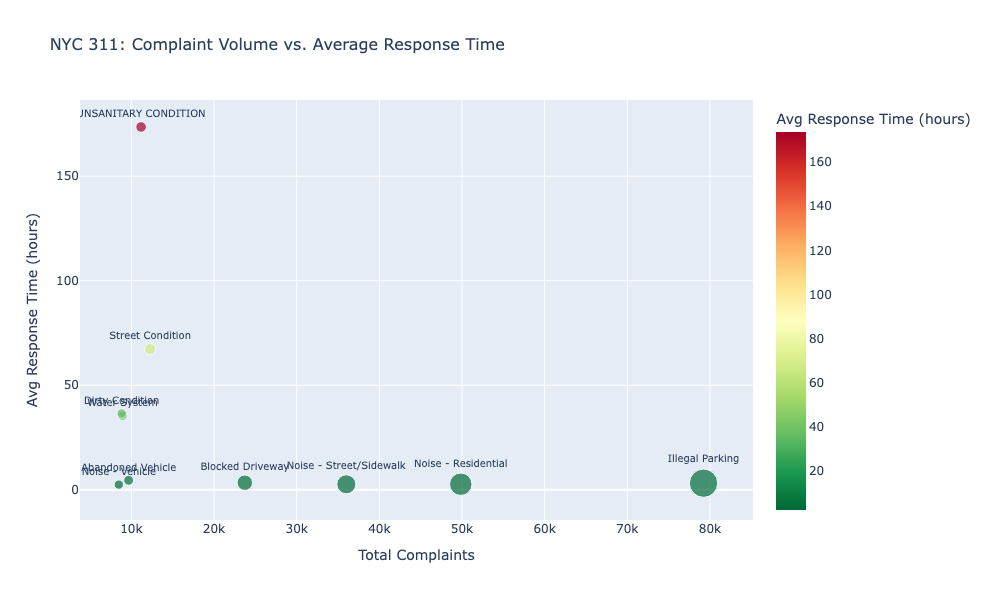

Saved: complaint_scatter.html


In [6]:
# Interactive chart — complaint volume vs response time
fig = px.scatter(
    complaint_stats,
    x='total',
    y='avg_response_hours',
    text='complaint_type',
    size='total',
    color='avg_response_hours',
    color_continuous_scale='RdYlGn_r',
    title='NYC 311: Complaint Volume vs. Average Response Time',
    labels={
        'total': 'Total Complaints',
        'avg_response_hours': 'Avg Response Time (hours)',
        'complaint_type': 'Complaint Type'
    }
)

fig.update_traces(textposition='top center', textfont_size=10)
fig.update_layout(
    height=600,
    showlegend=False,
    title_font_size=16
)
fig.write_html('complaint_scatter.html')
fig.show()
print("Saved: complaint_scatter.html")

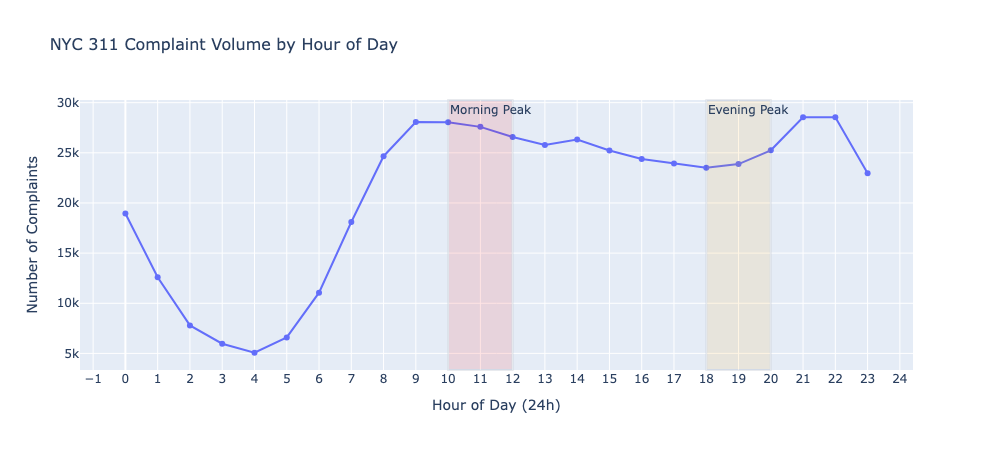

Saved: hourly_pattern.html


In [7]:
hourly = df_clean.groupby('hour').size().reset_index(name='count')

fig2 = px.line(
    hourly,
    x='hour',
    y='count',
    title='NYC 311 Complaint Volume by Hour of Day',
    labels={'hour': 'Hour of Day (24h)', 'count': 'Number of Complaints'},
    markers=True
)

fig2.update_layout(
    height=450,
    title_font_size=16,
    xaxis=dict(tickmode='linear', tick0=0, dtick=1)
)

# Highlight peak hours
fig2.add_vrect(x0=10, x1=12, fillcolor='red', opacity=0.1,
               annotation_text="Morning Peak", annotation_position="top left")
fig2.add_vrect(x0=18, x1=20, fillcolor='orange', opacity=0.1,
               annotation_text="Evening Peak", annotation_position="top left")

fig2.write_html('hourly_pattern.html')
fig2.show()
print("Saved: hourly_pattern.html")

## Temporal Patterns

Complaint volume follows a predictable daily cycle:
- **Minimum at 4-5am** (~5,000/hour) — the city's quiet hours
- **Morning plateau 9am-12pm** (~28,000/hour) — residents filing before/during work
- **Evening peak at 9-10pm** (~28,500/hour) — driven almost entirely by noise complaints (parties, music)

The evening noise spike has direct operational implications: staffing models should account for a second wave of high-volume, time-sensitive complaints late at night.

Training on 198,528 records...

Model Performance:
Mean Absolute Error: 11.51 hours
R² Score: 0.5311


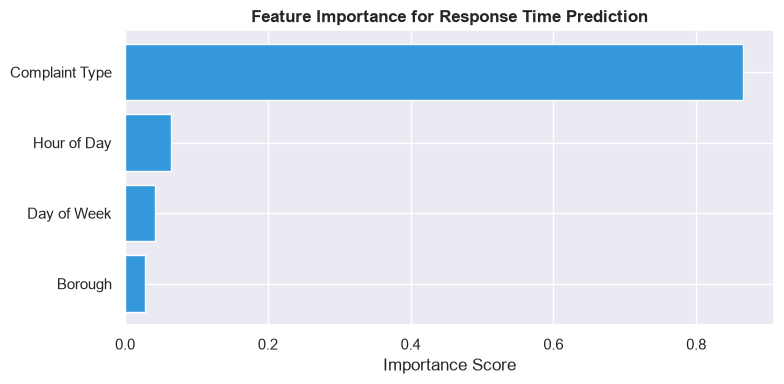

Saved: feature_importance.png


In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Prepare features for modeling
model_df = df_clean[
    (df_clean['response_hours'] > 0) & 
    (df_clean['response_hours'] < 500) &
    (df_clean['complaint_type'].isin(complaint_stats['complaint_type']))
].copy()

# Encode categorical features
le_borough = LabelEncoder()
le_complaint = LabelEncoder()

model_df['borough_enc'] = le_borough.fit_transform(model_df['borough'])
model_df['complaint_enc'] = le_complaint.fit_transform(model_df['complaint_type'])

features = ['borough_enc', 'complaint_enc', 'hour', 'day_of_week']
model_df['day_of_week_enc'] = LabelEncoder().fit_transform(model_df['day_of_week'])

X = model_df[['borough_enc', 'complaint_enc', 'hour', 'day_of_week_enc']]
y = model_df['response_hours']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train):,} records...")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Performance:")
print(f"Mean Absolute Error: {mae:.2f} hours")
print(f"R² Score: {r2:.4f}")

# Feature importance
importances = pd.DataFrame({
    'feature': ['Borough', 'Complaint Type', 'Hour of Day', 'Day of Week'],
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importances['feature'], importances['importance'], color='#3498db')
ax.set_title('Feature Importance for Response Time Prediction', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")

## Predictive Modeling

A **Random Forest Regressor** trained on complaint type, borough, hour of day, and day of week achieves:
- **MAE: 11.51 hours** — average prediction error on held-out test data
- **R²: 0.53** — these 4 features explain ~53% of response time variance

The remaining 47% likely reflects factors not captured in this dataset: staffing levels, inspector availability, complaint complexity, and weather. An R² of 0.53 from 4 simple features on noisy real-world data is a meaningful result — **complaint type is the strongest predictor**, consistent with the large variation in resolution times across complaint categories (2.6h for noise vs 173h for unsanitary conditions).

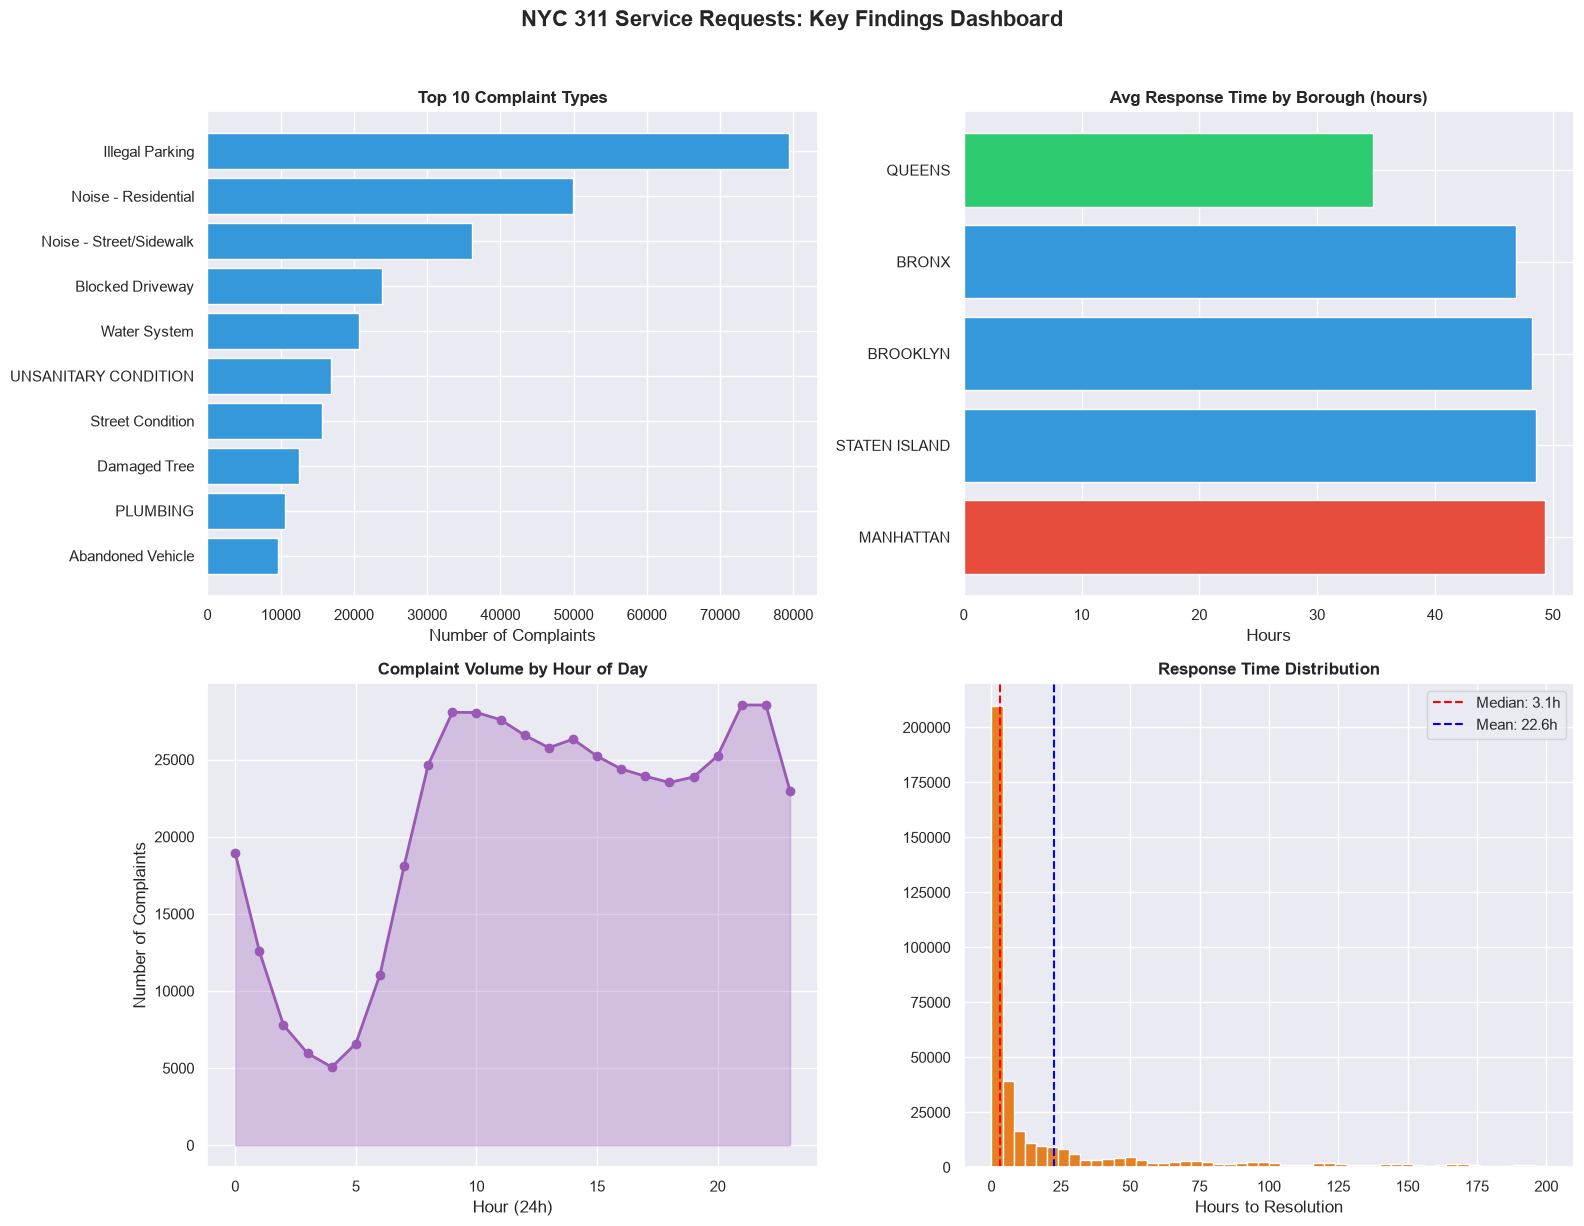

Saved: dashboard.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('NYC 311 Service Requests: Key Findings Dashboard', 
             fontsize=16, fontweight='bold', y=1.02)

# Panel 1: Top complaint types
top10 = df_clean['complaint_type'].value_counts().head(10)
axes[0,0].barh(top10.index[::-1], top10.values[::-1], color='#3498db')
axes[0,0].set_title('Top 10 Complaint Types', fontweight='bold')
axes[0,0].set_xlabel('Number of Complaints')

# Panel 2: Borough response times
axes[0,1].barh(borough_stats['borough'], borough_stats['avg_response_hours'],
               color=['#2ecc71' if b == 'QUEENS' else '#e74c3c' if b == 'MANHATTAN' 
                      else '#3498db' for b in borough_stats['borough']])
axes[0,1].set_title('Avg Response Time by Borough (hours)', fontweight='bold')
axes[0,1].set_xlabel('Hours')

# Panel 3: Hourly pattern
axes[1,0].plot(hourly['hour'], hourly['count'], color='#9b59b6', linewidth=2, marker='o')
axes[1,0].fill_between(hourly['hour'], hourly['count'], alpha=0.3, color='#9b59b6')
axes[1,0].set_title('Complaint Volume by Hour of Day', fontweight='bold')
axes[1,0].set_xlabel('Hour (24h)')
axes[1,0].set_ylabel('Number of Complaints')

# Panel 4: Response time distribution (log scale)
closed = df_clean[(df_clean['response_hours'] > 0) & (df_clean['response_hours'] < 200)]
axes[1,1].hist(closed['response_hours'], bins=50, color='#e67e22', edgecolor='white')
axes[1,1].axvline(closed['response_hours'].median(), color='red', 
                   linestyle='--', label=f"Median: {closed['response_hours'].median():.1f}h")
axes[1,1].axvline(closed['response_hours'].mean(), color='blue', 
                   linestyle='--', label=f"Mean: {closed['response_hours'].mean():.1f}h")
axes[1,1].set_title('Response Time Distribution', fontweight='bold')
axes[1,1].set_xlabel('Hours to Resolution')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dashboard.png")